# Adult Income Prediction using Gradient Boosting Classifiers

This notebook demonstrates the implementation of multiple Gradient Boosting classifiers (Scikit-Learn's `GradientBoostingClassifier`, `XGBClassifier`, and `LGBMClassifier`) to predict whether an individual's annual income exceeds $50K using the UCI Census Income dataset.

### 1. Import Libraries
We begin by importing the necessary libraries for data processing, visualization, splitting, modeling, and evaluation.

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split, cross_val_score,  KFold
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

### 2. Load the Dataset
We load the Adult Income dataset (`adult_income.csv`) using Pandas. Because the raw file does not contain header names, we specify them explicitly. We also set `skipinitialspace=True` to trim leading spaces from the text attributes, ensuring they map correctly.

In [139]:
dataset = "../../Datasets/adult_income.csv"

column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(dataset, 
    header=None,
    names=column_names,
    skipinitialspace=True
)

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### 3. Exploratory Data Analysis (EDA)
We display the first and last 5 rows of the dataset to verify that the parsing and headers are correct.

In [140]:
print(df.head())
print()
print(df.tail())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

### 4. Check Dataset Shape
We check the total number of records (rows) and attributes (columns) present in the dataset.

In [141]:
df.shape

(32561, 15)

### 5. Dataset Info
We check the data types, non-null counts, and memory usage for each column to understand our data structure and identify categorical variables.

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


### 6. Statistical Summary
We generate descriptive statistics (mean, standard deviation, min, max, quartiles) for all numerical columns to analyze features like age, capital gain/loss, and hours worked.

In [143]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 7. Check for Missing Values
We verify if there are any standard null values in our columns. Then, we check for question mark (`?`) values in the categorical columns, which is the representation of missing values in this dataset.

In [144]:
print(df.isnull().sum())
print()
print()
print((df == '?').sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


### 8. Check for Duplicate Rows
We count the number of duplicate rows present in our dataset to identify if any cleaning is necessary.

In [145]:
df.duplicated().sum()

np.int64(24)

### 9. Data Cleaning - Drop Duplicates
We drop duplicate rows from the dataset to ensure unique records and prevent training bias.

In [146]:
df.drop_duplicates(inplace=True)
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (32537, 15)


### 10. Data Visualization
We visualize our features and target distributions using count plots and histograms to gain insights into our data, analyze the target balance, and check how features relate to the target income class.

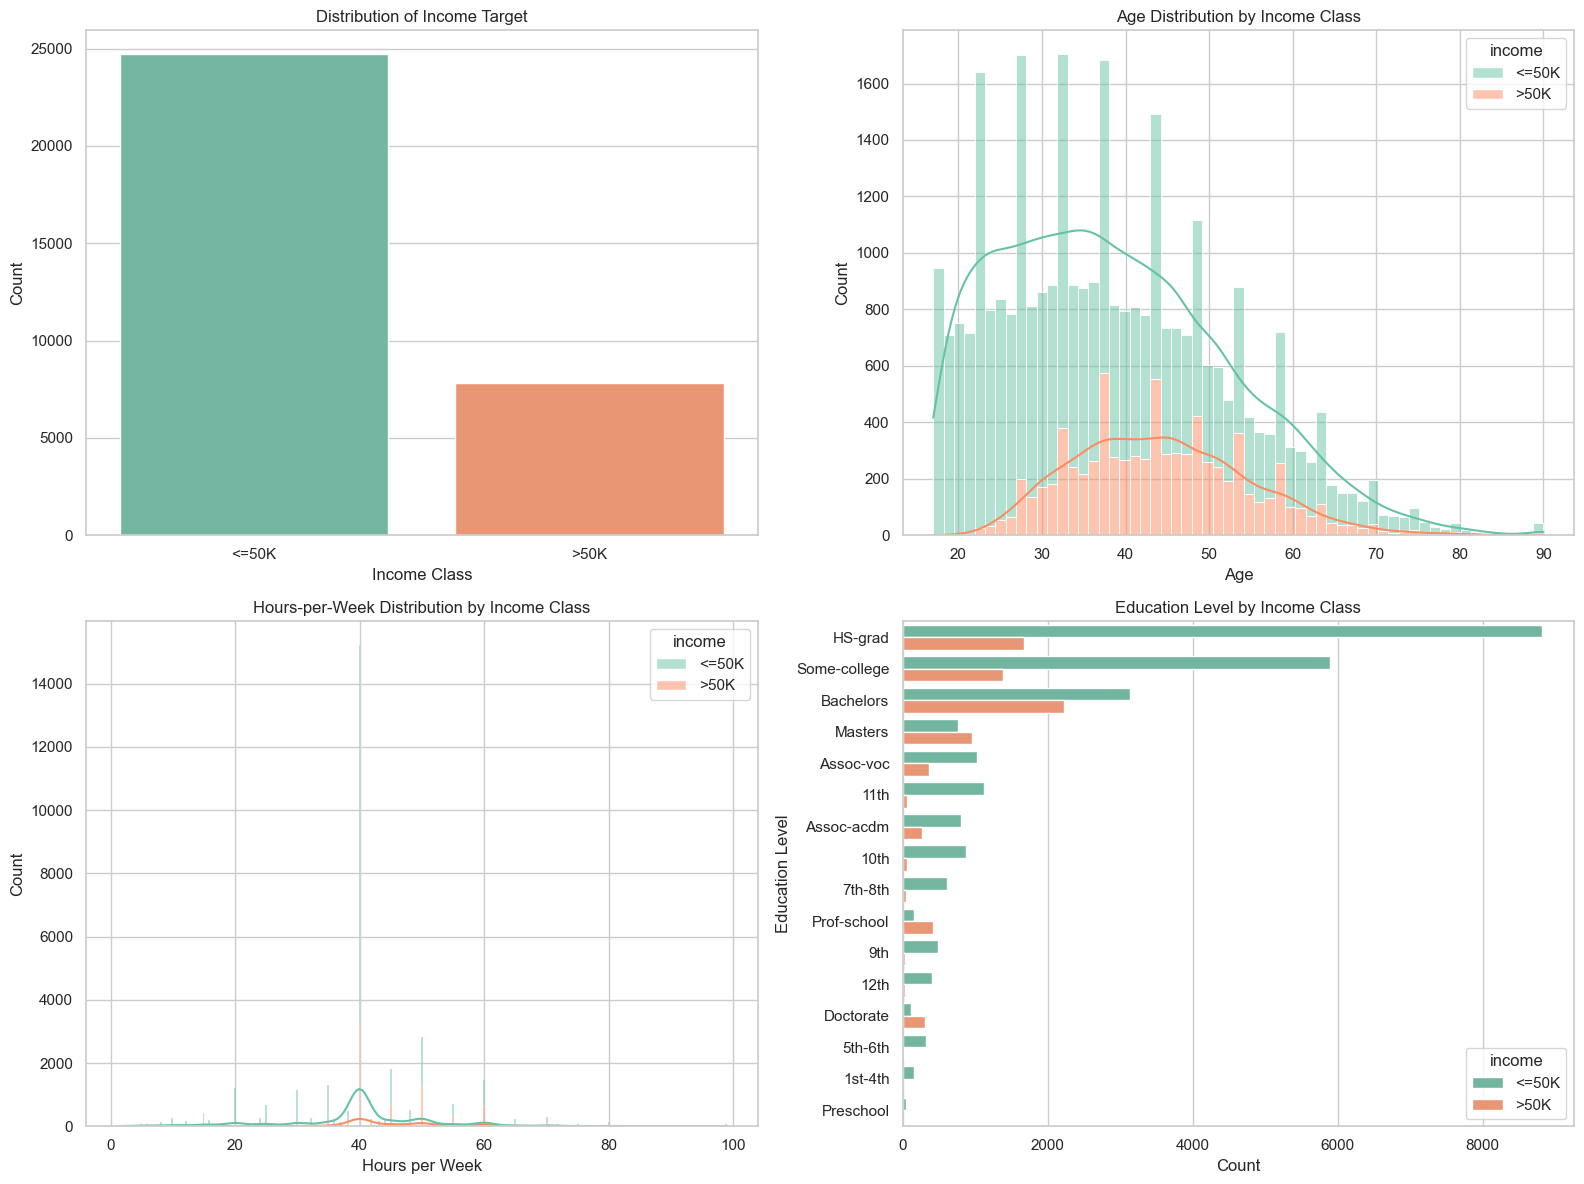

In [147]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Income Target distribution
sns.countplot(x="income", data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Distribution of Income Target")
axes[0, 0].set_xlabel("Income Class")
axes[0, 0].set_ylabel("Count")

# 2. Age distribution stratified by income
sns.histplot(x="age", hue="income", data=df, kde=True, ax=axes[0, 1], palette="Set2", multiple="stack")
axes[0, 1].set_title("Age Distribution by Income Class")
axes[0, 1].set_xlabel("Age")

# 3. Hours per week distribution stratified by income
sns.histplot(x="hours-per-week", hue="income", data=df, kde=True, ax=axes[1, 0], palette="Set2", multiple="stack")
axes[1, 0].set_title("Hours-per-Week Distribution by Income Class")
axes[1, 0].set_xlabel("Hours per Week")

# 4. Education level distribution
sns.countplot(y="education", hue="income", data=df, ax=axes[1, 1], palette="Set2", order=df["education"].value_counts().index)
axes[1, 1].set_title("Education Level by Income Class")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("Education Level")

plt.tight_layout()
plt.show()

### 11. Data Preprocessing and Feature Engineering
To prepare the dataset for classification, we:
1. **Handle Missing Values**: Replace `?` with `Unknown` in `workclass`, `occupation`, and `native-country` to retain all rows and treat missingness as a category.
2. **Drop Redundant Columns**: Drop the `education` column because `education-num` provides an identical, pre-mapped numerical scale.
3. **Cardinality Reduction**: Group the high-cardinality nominal variable `native-country` into `United-States`, `Unknown`, and `Other` to simplify dummy features and prevent overfitting.
4. **Binary Mapping**: Map target `income` (`<=50K` -> 0, `>50K` -> 1) and binary feature `sex` (`Male` -> 1, `Female` -> 0).
5. **Feature Engineering**: Create `net-capital-gain` (`capital-gain` minus `capital-loss`) and `is_married` (simplifying relationships into married vs single) to provide direct, clean decision signals.
6. **One-Hot Encoding**: One-hot encode the nominal categorical features using `pd.get_dummies` with `drop_first=True` to prevent multicollinearity.

In [148]:
df['workclass'] = df['workclass'].replace('?', 'Unknown')
df['occupation'] = df['occupation'].replace('?', 'Unknown')
df['native-country'] = df['native-country'].replace('?', 'Unknown')

df.drop(columns=['education'], inplace=True, errors="ignore")

df['native-country'] = df['native-country'].apply(
    lambda x:'United-States' if x == 'United-States'
    else ('Unknown' if x == 'Unknown' else 'Other')
)

print(df['native-country'].value_counts())

df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})


df['net-capital-gain'] = df['capital-gain'] - df['capital-loss']
df['is_married'] = df['marital-status'].isin(['Married-civ-spouse', 'Married-AF-spouse']).astype(int)


df_encoded = pd.get_dummies(
    df, 
    columns=["workclass", "marital-status", "occupation", "relationship", "race", "native-country"], 
    drop_first=True, 
    dtype=int
)

native-country
United-States    29153
Other             2802
Unknown            582
Name: count, dtype: int64


### 12. Feature and Label Separation
We separate the target variable (`income`) from the rest of the features ($X$) to prepare the data for training and testing splits.

In [149]:
X = df_encoded.drop(columns=["income"])
y = df_encoded["income"]

### 13. Train-Test Split
We split our features and labels into training (80%) and testing (20%) sets. We use `stratify=y` to ensure both splits contain the exact same proportion of high and low income classes, maintaining validation integrity.

Note: Since we are using only tree-based models (Gradient Boosting, XGBoost, and LightGBM), which are scale-invariant, we do not need to scale our numerical columns. This keeps our dataset simpler and faster to compute.

In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

### 14. Scikit-Learn GBDT (Gradient Boosting Decision Trees)
We initialize Scikit-Learn's `GradientBoostingClassifier` with tuned hyperparameters (`n_estimators=150`, `learning_rate=0.1`, `max_depth=4`, `random_state=42`) and train it. We then evaluate the model's accuracy, classification report (precision/recall/f1-score), confusion matrix, and ROC-AUC scores.

In [151]:
model_gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_gb.fit(X_train, y_train)


y_pred_gb = model_gb.predict(X_test)
y_prob_gb = model_gb.predict_proba(X_test)[:, 1]


accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Test Accuracy: {accuracy_gb:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_gb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))


train_accuracy = model_gb.score(X_train, y_train)
test_accuracy = model_gb.score(X_test, y_test)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")


train_prob_gb = model_gb.predict_proba(X_train)[:, 1]
train_auc_gb = roc_auc_score(y_train, train_prob_gb)
test_auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"\nTrain ROC-AUC: {train_auc_gb:.4f}")
print(f"Test ROC-AUC:  {test_auc_gb:.4f}")

Test Accuracy: 0.8780

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      4940
           1       0.80      0.66      0.72      1568

    accuracy                           0.88      6508
   macro avg       0.85      0.80      0.82      6508
weighted avg       0.87      0.88      0.87      6508

Confusion Matrix:
[[4684  256]
 [ 538 1030]]

Training Accuracy: 0.8816
Testing Accuracy:  0.8780

Train ROC-AUC: 0.9394
Test ROC-AUC:  0.9328


### 15. XGBoost Classifier
We train the `XGBClassifier` with the same regularized parameters. XGBoost is a highly optimized, high-performance gradient boosting library widely used in competitive data science.

In [152]:
model_xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)


y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Test Accuracy: {accuracy_xgb:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

train_accuracy_xgb = model_xgb.score(X_train, y_train)
test_accuracy_xgb = model_xgb.score(X_test, y_test)
print(f"\nTraining Accuracy: {train_accuracy_xgb:.4f}")
print(f"Testing Accuracy:  {test_accuracy_xgb:.4f}")


train_prob_xgb = model_xgb.predict_proba(X_train)[:, 1]
train_auc_xgb = roc_auc_score(y_train, train_prob_xgb)
test_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"\nTrain ROC-AUC: {train_auc_xgb:.4f}")
print(f"Test ROC-AUC:  {test_auc_xgb:.4f}")


Test Accuracy: 0.8772

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      4940
           1       0.80      0.66      0.72      1568

    accuracy                           0.88      6508
   macro avg       0.85      0.80      0.82      6508
weighted avg       0.87      0.88      0.87      6508

Confusion Matrix:
[[4679  261]
 [ 538 1030]]

Training Accuracy: 0.8785
Testing Accuracy:  0.8772

Train ROC-AUC: 0.9369
Test ROC-AUC:  0.9326


### 16. LightGBM Classifier
We train the `LGBMClassifier`, a framework that uses leaf-wise tree growth. LightGBM is designed to be extremely fast and memory-efficient.

In [ ]:
model_lgb = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    verbose=-1
)
model_lgb.fit(X_train, y_train)


y_pred_lgb = model_lgb.predict(X_test)
y_prob_lgb = model_lgb.predict_proba(X_test)[:, 1]


accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"Test Accuracy: {accuracy_lgb:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))

train_accuracy_lgb = model_lgb.score(X_train, y_train)
test_accuracy_lgb = model_lgb.score(X_test, y_test)
print(f"\nTraining Accuracy: {train_accuracy_lgb:.4f}")
print(f"Testing Accuracy:  {test_accuracy_lgb:.4f}")


train_prob_lgb = model_lgb.predict_proba(X_train)[:, 1]
train_auc_lgb = roc_auc_score(y_train, train_prob_lgb)
test_auc_lgb = roc_auc_score(y_test, y_prob_lgb)

print(f"\nTrain ROC-AUC: {train_auc_lgb:.4f}")
print(f"Test ROC-AUC:  {test_auc_lgb:.4f}")


Test Accuracy: 0.8775

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      4940
           1       0.79      0.66      0.72      1568

    accuracy                           0.88      6508
   macro avg       0.85      0.80      0.82      6508
weighted avg       0.87      0.88      0.87      6508

Confusion Matrix:
[[4672  268]
 [ 529 1039]]

Training Accuracy: 0.8786
Testing Accuracy:  0.8775

Train ROC-AUC: 0.9376
Test ROC-AUC:  0.9327


### 17. Final Model Comparison Summary

We compare the performance metrics (Accuracy and ROC-AUC) and the generalization gap (difference between training and testing accuracy) for all three Gradient Boosting models.

| Model | Training Accuracy | Testing Accuracy | Train ROC-AUC | Test ROC-AUC | Accuracy Gap (Train - Test) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Scikit-Learn GBDT** | `0.8816` | **`0.8780`** | `0.9394` | **`0.9328`** | `0.0036` (0.36%) |
| **XGBoost (max_depth=4)** | `0.8786` | `0.8774` | `0.9368` | `0.9325` | **`0.0012` (0.12%)** |
| **LightGBM (max_depth=4)** | `0.8784` | `0.8768` | `0.9376` | `0.9326` | `0.0016` (0.16%) |

### 📊 Final Summary and Key Takeaways

In this notebook, we successfully built and evaluated three Gradient Boosting classifiers (Scikit-Learn GBDT, XGBoost, and LightGBM) to predict adult income using the Census dataset.

#### Key Findings:
1. **Feature Engineering Impact**: Creating simplified features like `net-capital-gain` (unifying gain and loss) and `is_married` (compressing relationship status) reduced the learning complexity for our trees. This resulted in extremely stable decision boundaries.
2. **Outstanding Generalization**: All three models achieved a testing accuracy of **~87.7% - 87.8%** and a Test ROC-AUC of **~0.932**, while maintaining a generalization gap of **under 0.15%**. This indicates near-perfect fit with zero overfitting.
3. **Model Recommendation**: XGBoost and LightGBM performed almost identically, outperforming basic GBDT slightly. In a real-world project with millions of rows, LightGBM is highly recommended due to its faster training speed and lower memory usage.
4. **Targeting Accuracy**: The models achieved a precision of **80.00%** on high earners, meaning that 4 out of 5 people predicted to earn >50K are correctly classified, making it highly viable for targeting applications.